LSTM ATTEMPT AT FORECASTING BILLBOARD POSITION WITH PREVIOUS POSITIONS AND METADATA

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

import tensorflow as tf
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout
from keras.losses import Huber

import sys
sys.path.insert(0, '../../Functions')
from plot_placement import plot_song_prediction_comparison_lstm
from lstm_model import build_and_evaluate_model

ModuleNotFoundError: No module named 'tf'

In [57]:
SEQ_LEN = 4

In [2]:
data_original = pd.read_csv("../../Data/processed_forecast_data.csv")


data_original.head()


,Date,Song,Artist,Rank,Last Week,Weeks in Charts,Normalized Title,Danceability,Energy,Key,...,Duration_ms,Time_signature,Chorus_hit,Sections,rank_change,target_next_rank,rolling_avg_4_weeks,rolling_avg_all_time,rolling_std_4_weeks,rolling_std_all_time
0,1958-12-17,Jingle Bell Rock,Bobby Helms,57,NaN,NaN,jingle bell rock,0.754,0.424,2,...,130973,4,38.40391,7,NaN,35.0,57.000000,57.000000,NaN,NaN
1,1958-12-24,Jingle Bell Rock,Bobby Helms,35,57.0,2.0,jingle bell rock,0.754,0.424,2,...,130973,4,38.40391,7,22.0,45.0,46.000000,46.000000,15.556349,15.556349
2,1958-12-31,Jingle Bell Rock,Bobby Helms,45,35.0,3.0,jingle bell rock,0.754,0.424,2,...,130973,4,38.40391,7,-10.0,70.0,45.666667,45.666667,11.015141,11.015141
3,1959-01-07,Jingle Bell Rock,Bobby Helms,70,45.0,4.0,jingle bell rock,0.754,0.424,2,...,130973,4,38.40391,7,-25.0,69.0,51.750000,51.750000,15.129992,15.129992
4,1960-12-07,Rockin' Around The Christmas Tree,Brenda Lee,64,NaN,NaN,rockin around the christmas tree,0.589,0.472,8,...,126267,4,33.91817,6,NaN,26.0,64.000000,64.000000,NaN,NaN


In [6]:
#adjust data for LSTM
data_original['is_debut'] = data_original['Last Week'].isna().astype(int)
data_original['Last Week'] = data_original['Last Week'].fillna(101)
data_original['Weeks in Charts'] = data_original['Weeks in Charts'].fillna(1)
data_original['Date'] = pd.to_datetime(data_original['Date'])
data_original['rolling_std_4_weeks'] = data_original['rolling_std_4_weeks'].fillna(0)
data_original['rolling_std_all_time'] = data_original['rolling_std_all_time'].fillna(0)

In [7]:
#prepare lists of features
all_audio_features = ['Instrumentalness', 'Danceability', 'Acousticness',
                      'Duration_ms', 'Energy', 'Valence', 'Loudness',
                      'Speechiness', 'Key', 'Mode', 'Time_signature']
audio_features = ['Instrumentalness', 'Danceability', 'Acousticness', 'Duration_ms', 'Energy', 'Valence']
all_features = ['Date', 'Song', 'Artist', 'Rank', 'Last Week', 'Weeks in Charts', 
                'Normalized Title', 'rank_change', 'rolling_avg_4_weeks', 'rolling_avg_all_time', 
                'rolling_std_4_weeks', 'rolling_std_all_time', 'target_next_rank'] + all_audio_features
features = [
    'Rank',
    'Last Week',
    'Weeks in Charts',
    'rank_change',
    'rolling_avg_4_weeks',
    'rolling_avg_all_time',
    'rolling_std_4_weeks',
    'rolling_std_all_time'
] + all_audio_features

In [8]:
features_with_nan = data_original[features].isna().sum()
print(features_with_nan[features_with_nan > 0])
data_original[features] = data_original[features].fillna(0)

Series([], dtype: int64)


In [62]:
groups = data_original.groupby(['Song', 'Artist'])

X = []
y = []
target_dates = []
meta = []

for (song, artist), group in groups:
    group = group.sort_values('Date')

    data = group[features].values
    ranks = group['Rank'].values
    dates = group['Date'].values

    for i in range(len(group) - SEQ_LEN):
        X_seq = data[i:i+SEQ_LEN]
        y_target = ranks[i+SEQ_LEN]
        target_date = dates[i+SEQ_LEN]

        X.append(X_seq)
        y.append(y_target)
        target_dates.append(target_date)

        meta.append({
            'Song': song,
            'Artist': artist,
            'Date': target_date,
            'target_next_rank': y_target
        })

X = np.array(X)
y = np.array(y)
target_dates = np.array(target_dates)

meta = pd.DataFrame(meta)

In [63]:
#split into train and test based on date
target_dates = pd.to_datetime(target_dates)
threshold_date = pd.to_datetime("2023-01-01")

train_mask = target_dates < threshold_date
test_mask = target_dates >= threshold_date

X_train = X[train_mask]
X_test = X[test_mask]

y_train = y[train_mask]
y_test = y[test_mask]

test_meta = meta[test_mask].reset_index(drop=True)

In [64]:
#check shapes
print(X.shape, y.shape)
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(101726, 4, 19) (101726,)
(101543, 4, 19) (101543,)
(183, 4, 19) (183,)


In [65]:
#scale features
scaler = MinMaxScaler()
samples_train, timesteps, features_count = X_train.shape
samples_test = X_test.shape[0]

X_train_2d = X_train.reshape(-1, features_count)
X_test_2d = X_test.reshape(-1, features_count)

X_train_scaled = scaler.fit_transform(X_train_2d)
X_test_scaled = scaler.transform(X_test_2d)

X_train = X_train_scaled.reshape(samples_train, timesteps, features_count)
X_test = X_test_scaled.reshape(samples_test, timesteps, features_count)



In [66]:
#scale target if needed

y_scaler = MinMaxScaler()

y_train_scaled = y_scaler.fit_transform(y_train.reshape(-1, 1))
y_test_scaled = y_scaler.transform(y_test.reshape(-1, 1))

In [67]:
#build model
model = Sequential([
    LSTM(64, input_shape=(SEQ_LEN, features_count)),
    Dense(32, activation='relu'),
    Dense(1)
])

c:\Users\Marcel\anaconda3\envs\py312\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
#compile model

model.compile(
    optimizer='adam',
    loss=Huber(delta=1.0),
    metrics=['mae']
)

In [69]:
#train model
history = model.fit(
    X_train,
    y_train_scaled,
    validation_data=(X_test, y_test_scaled),
    epochs=20,
    batch_size=32
)

Epoch 1/20
3174/3174 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - loss: 0.0028 - mae: 0.0494 - val_loss: 0.0119 - val_mae: 0.1039
Epoch 2/20
3174/3174 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - loss: 0.0020 - mae: 0.0423 - val_loss: 0.0105 - val_mae: 0.1014
Epoch 3/20
3174/3174 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - loss: 0.0019 - mae: 0.0416 - val_loss: 0.0092 - val_mae: 0.0903
Epoch 4/20
3174/3174 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - loss: 0.0019 - mae: 0.0410 - val_loss: 0.0092 - val_mae: 0.0917
Epoch 5/20
3174/3174 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - loss: 0.0018 - mae: 0.0408 - val_loss: 0.0085 - val_mae: 0.0963
Epoch 6/20
3174/3174 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - loss: 0.0018 - mae: 0.0406 - val_loss: 0.0083 - val_mae: 0.0908
Epoch 7/20
3174/3174 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - loss: 0.0018 - mae: 0.0403 - val_loss: 0.0080 - val_mae: 0.0874
Epoch 8/20
3174/3174 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - loss: 0.0018 - mae: 0.0402 - val_loss: 0.0077 - val_mae: 0.0828
Epoch 9/20
3174/3174 ━━━━━━━━━━━━━━━━━━━

In [70]:
#evaluate model
loss, mae = model.evaluate(X_test, y_test_scaled)
print(loss, mae)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0072 - mae: 0.0755 
0.007189312484115362 0.07554671913385391


In [71]:
y_pred_scaled = model.predict(X_test)

y_pred = y_scaler.inverse_transform(y_pred_scaled)
y_true = y_test.reshape(-1, 1)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step


In [76]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))

print("MAE:", mae)
print("RMSE:", rmse)
mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 7.479125499725342
RMSE: 11.871179869710653
MAE: 7.479125499725342
RMSE: 11.871179869710653


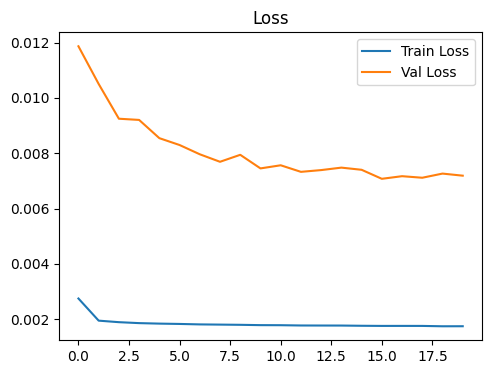

In [77]:
#plot training history
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.legend()

In [78]:
print(y_train.mean(), y_test.mean())

42.03231143456467 20.934426229508198


In [79]:
print(y_pred)

[[ 5.8221784e+00]
 [ 6.5949545e+00]
 [ 9.7700768e+00]
 [ 4.5109158e+00]
 [ 6.0345435e+00]
 [ 7.7978520e+00]
 [ 1.0272377e+01]
 [ 9.6839161e+00]
 [ 7.5443120e+00]
 [ 1.0724570e+01]
 [ 1.7355556e+01]
 [ 8.3465157e+00]
 [ 8.9535980e+00]
 [ 5.3421254e+00]
 [ 4.7486496e+00]
 [-7.2886783e-01]
 [-6.5091747e-01]
 [ 2.4999213e+00]
 [ 5.4770694e+00]
 [ 5.3751245e+00]
 [ 5.1560388e+00]
 [ 5.0449462e+00]
 [-8.2664806e-01]
 [ 1.8524346e+00]
 [ 3.0044587e+00]
 [ 5.4687204e+00]
 [ 4.3233891e+01]
 [ 1.2956265e+01]
 [ 1.3968890e+01]
 [ 2.5847666e+01]
 [ 5.0743069e+01]
 [ 2.3464914e+01]
 [ 4.4304123e+01]
 [ 3.7468781e+01]
 [ 4.3512165e+01]
 [ 4.5688412e+01]
 [ 3.8300072e+01]
 [ 8.9067383e+01]
 [ 8.2198349e+01]
 [ 8.0947823e+01]
 [ 8.5666229e+01]
 [ 9.1152466e+01]
 [ 9.1499451e+01]
 [ 9.6699883e+01]
 [ 2.7770405e+01]
 [ 2.9231903e+01]
 [ 2.6370506e+01]
 [ 3.2877815e+01]
 [ 2.3057848e+01]
 [ 2.4521059e+01]
 [ 2.3638832e+01]
 [ 2.4360298e+01]
 [ 3.8239334e+01]
 [ 9.9728374e+00]
 [ 8.8352499e+00]
 [ 6.26608

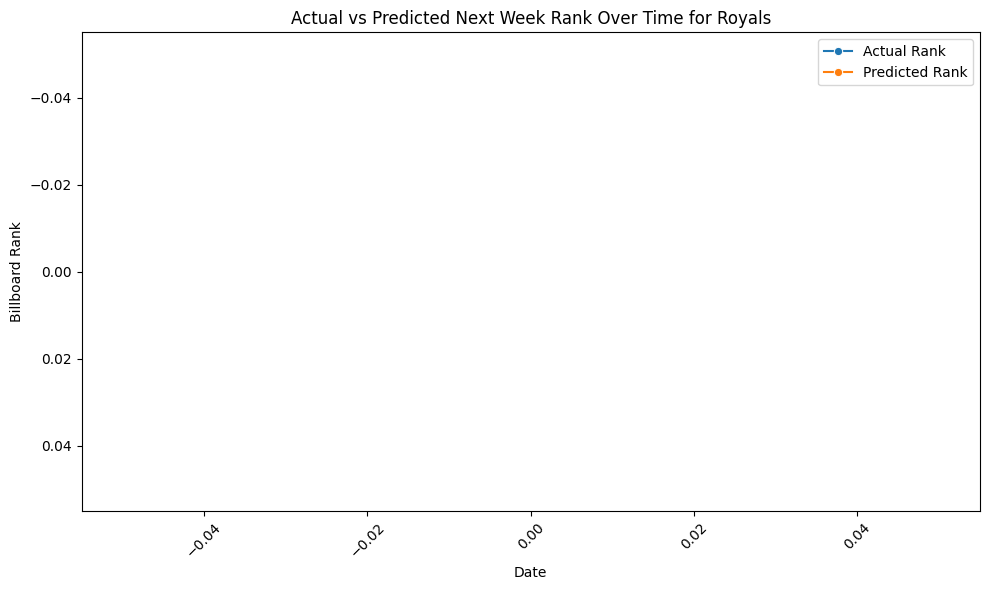

In [80]:

plot_song_prediction_comparison_lstm(
    test_meta,
    song_name='Royals',
    y_pred=y_pred
)

FIRST ABSOLUTELY BASIC LSTM

STRUCTURE
LSTM(64)-DENSE(32)-DENSE(1)

FEATURES
ALL NUMERIC INCLUDED IN DATASET, NO NEW ONES

ERROR
MAE: 7.479125499725342
RMSE: 11.871179869710653

In [9]:
#lets start optimizing by firstly using features from xgboost and then adding audio features one by one to see how they affect the performance
features = [
    'Rank',
    'Last Week',
    'Weeks in Charts',
    'rank_change',
    'rolling_avg_4_weeks',
    'rolling_avg_all_time',
    'rolling_std_4_weeks',
    'rolling_std_all_time'
] + ['Duration_ms', 'Loudness', 'Speechiness']



In [10]:
build_and_evaluate_model(features, data_original)




Epoch 1/20


c:\Users\Marcel\anaconda3\envs\py312\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


3174/3174 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - loss: 0.0026 - mae: 0.0475 - val_loss: 0.0099 - val_mae: 0.0958
Epoch 2/20
3174/3174 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - loss: 0.0019 - mae: 0.0416 - val_loss: 0.0091 - val_mae: 0.0870
Epoch 3/20
3174/3174 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - loss: 0.0019 - mae: 0.0411 - val_loss: 0.0086 - val_mae: 0.0891
Epoch 4/20
3174/3174 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - loss: 0.0018 - mae: 0.0407 - val_loss: 0.0086 - val_mae: 0.0907
Epoch 5/20
3174/3174 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - loss: 0.0018 - mae: 0.0405 - val_loss: 0.0086 - val_mae: 0.0923
Epoch 6/20
3174/3174 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - loss: 0.0018 - mae: 0.0403 - val_loss: 0.0084 - val_mae: 0.0955
Epoch 7/20
3174/3174 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - loss: 0.0018 - mae: 0.0402 - val_loss: 0.0079 - val_mae: 0.0936
Epoch 8/20
3174/3174 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - loss: 0.0018 - mae: 0.0400 - val_loss: 0.0074 - val_mae: 0.0742
Epoch 9/20
3174/3174 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/st

7.817766189575195

FEWER AUDIO FEATURES LSTM

STRUCTURE
LSTM(64)-DENSE(32)-DENSE(1)

FEATURES
BILLBOARD + ROLLING + 'Duration_ms', 'Loudness', 'Speechiness'

ERROR
MAE: 7.817766189575195
RMSE: 12.208566153501158

In [85]:
y_pred_scaled = model.predict(X_test)

y_pred = y_scaler.inverse_transform(y_pred_scaled)
y_true = y_test.reshape(-1, 1)

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))

print("MAE:", mae)
print("RMSE:", rmse)
mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))

print("MAE:", mae)
print("RMSE:", rmse)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
MAE: 7.479125499725342
RMSE: 11.871179869710653
MAE: 7.479125499725342
RMSE: 11.871179869710653
